# Modelos de Aprendizado Não Supervisionado

1. Estrutura inicial e carregamento da base
2. EDA focada em clustering e limpeza inicial de texto


## 0. Importacao e visualizacao de dados


In [ ]:
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuracao visual (reaproveitada do notebook supervisionado)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# Carregar dataset principal
DATASET_PATH = '../datasets/dataset_avaliacoes.csv'
df = pd.read_csv(DATASET_PATH, sep=',')

print("Dataset carregado com sucesso!")
print(f"Arquivo: {DATASET_PATH}")
print(f"Forma do dataset: {df.shape}")
print("\nPrimeiras 5 linhas:")
df.head()


Dataset carregado com sucesso!
Arquivo: ../datasets/dataset_avaliacoes.csv
Forma do dataset: (15501, 4)

Primeiras 5 linhas:


,ID_avaliacao,avaliacao,nota,sentimento
0,81841,"Esse smartphone superou minhas expectativas, r...",5,positivo
1,28031,o cheiro e muito desagradavel!! pra quem se in...,2,negativo
2,91332,"Eu fiz a compra a loja não entregou o produto,...",1,negativo
3,110045,"Atendeu minhas expectativas, só achei a luz ru...",4,positivo
4,36929,"Gostei muito, só achei que ficou a desejar a q...",5,positivo


## 1. Analise inicial da estrutura da base

Nesta etapa, analisamos estrutura e qualidade dos dados para confirmar se a base e adequada para agrupamento.


In [ ]:
print("=" * 70)
print("INFORMACOES ESTRUTURAIS DO DATASET")
print("=" * 70)

print(f"\nForma (linhas, colunas): {df.shape}")
print("\nTipos de dados por coluna:")
print(df.dtypes)

mem_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"\nMemoria utilizada: {mem_mb:.2f} MB")

# Comprimento de texto para EDA
df['length_chars'] = df['avaliacao'].astype(str).apply(len)
df['length_words'] = df['avaliacao'].astype(str).apply(lambda x: len(x.split()))

print("\nResumo de comprimento (caracteres):")
print(df['length_chars'].describe())

print("\nResumo de comprimento (palavras):")
print(df['length_words'].describe())


INFORMACOES ESTRUTURAIS DO DATASET

Forma (linhas, colunas): (15501, 4)

Tipos de dados por coluna:
ID_avaliacao    int64
avaliacao         str
nota            int64
sentimento        str
dtype: object

Memoria utilizada: 4.10 MB

Resumo de comprimento (caracteres):
count    15501.000000
mean       141.361396
std        122.421696
min         46.000000
25%         70.000000
50%         99.000000
75%        164.000000
max       2139.000000
Name: length_chars, dtype: float64

Resumo de comprimento (palavras):
count    15501.000000
mean        24.017031
std         21.582232
min          1.000000
25%         11.000000
50%         17.000000
75%         28.000000
max        385.000000
Name: length_words, dtype: float64


In [ ]:
print("=" * 70)
print("QUALIDADE DOS DADOS")
print("=" * 70)

empty_values = df.isnull().sum()
percentual_vazios = (empty_values / len(df) * 100).round(2)

print("\nValores vazios por coluna:")
for col in df.columns:
    print(f"  {col:20} - Vazios: {empty_values[col]:5d} ({percentual_vazios[col]:6.2f}%)")

linhas_com_vazio = df.isnull().any(axis=1).sum()
print(f"\nTotal de linhas com algum valor vazio: {linhas_com_vazio}")

duplicadas = df.duplicated(subset=['avaliacao']).sum()
print(f"Total de avaliacoes duplicadas (texto igual): {duplicadas}")

if empty_values.sum() == 0:
    print("\nNenhum valor vazio encontrado no dataset.")


QUALIDADE DOS DADOS

Valores vazios por coluna:
  ID_avaliacao         - Vazios:     0 (  0.00%)
  avaliacao            - Vazios:     0 (  0.00%)
  nota                 - Vazios:     0 (  0.00%)
  sentimento           - Vazios:     0 (  0.00%)
  length_chars         - Vazios:     0 (  0.00%)
  length_words         - Vazios:     0 (  0.00%)

Total de linhas com algum valor vazio: 0
Total de avaliacoes duplicadas (texto igual): 129

Nenhum valor vazio encontrado no dataset.


## 2. EDA focada em agrupamento

Para clustering, vamos observar distribuicoes de tamanho de texto e nota (sem usar rotulo de sentimento para treinar modelos).


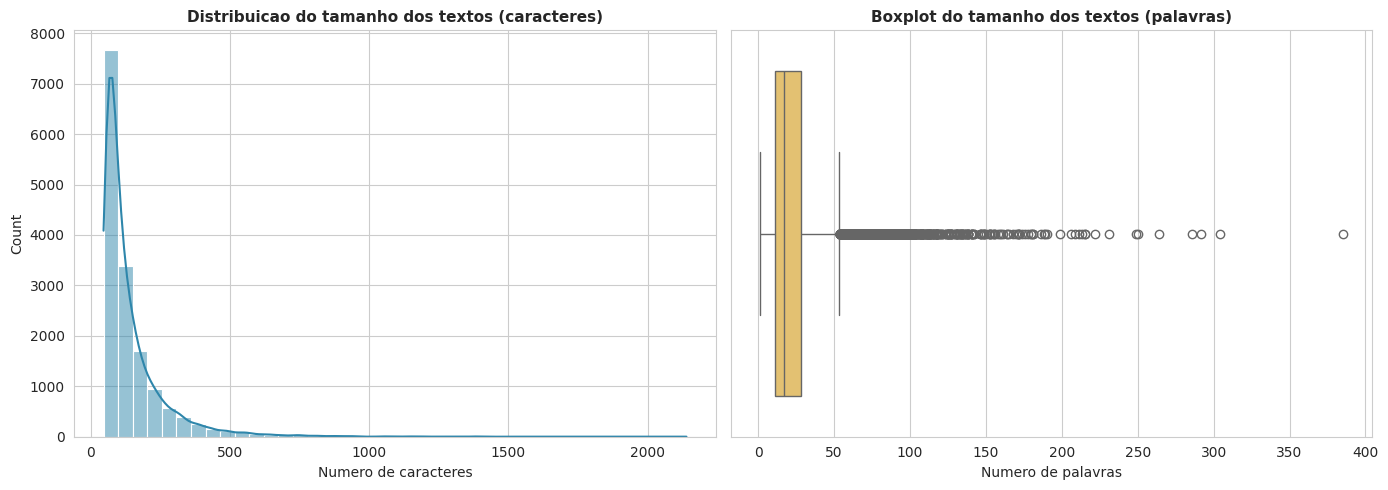

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['length_chars'], bins=40, kde=True, ax=axes[0], color='#2E86AB')
axes[0].set_title('Distribuicao do tamanho dos textos (caracteres)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Numero de caracteres')

sns.boxplot(x=df['length_words'], ax=axes[1], color='#F6C85F')
axes[1].set_title('Boxplot do tamanho dos textos (palavras)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Numero de palavras')

plt.tight_layout()
plt.show()


DISTRIBUICAO DE NOTAS
nota
1    5655
2    1956
4    3296
5    4594
Name: count, dtype: int64


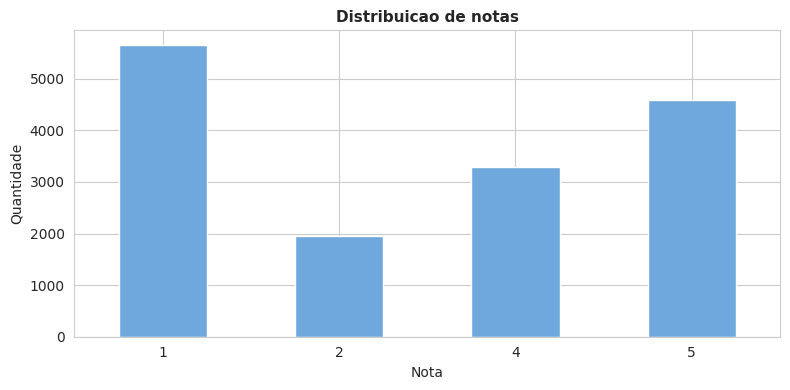

In [ ]:
print("DISTRIBUICAO DE NOTAS")
nota_counts = df['nota'].value_counts().sort_index()
print(nota_counts)

plt.figure(figsize=(8, 4))
nota_counts.plot(kind='bar', color='#6FA8DC')
plt.title('Distribuicao de notas', fontsize=11, fontweight='bold')
plt.xlabel('Nota')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 3. Limpeza inicial de texto

Aplicamos uma limpeza leve para preparar dados para vetorizacao (TF-IDF) nas proximas etapas.


In [ ]:
def limpar_texto(texto: str) -> str:
    texto = str(texto).lower().strip()

    # remove acentos
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join(ch for ch in texto if not unicodedata.combining(ch))

    # remove caracteres especiais e numeros, preservando letras e espaco
    texto = re.sub(r'[^a-z\s]', ' ', texto)

    # normaliza espacos
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto


df['avaliacao_limpa'] = df['avaliacao'].astype(str).apply(limpar_texto)

print('Exemplos de limpeza:')
for i in range(3):
    original = df.loc[i, 'avaliacao']
    limpa = df.loc[i, 'avaliacao_limpa']
    print(f"\n[{i+1}] Original: {original[:160]}")
    print(f"[{i+1}] Limpa:    {limpa[:160]}")


Exemplos de limpeza:

[1] Original: Esse smartphone superou minhas expectativas, recomendo
[1] Limpa:    esse smartphone superou minhas expectativas recomendo

[2] Original: o cheiro e muito desagradavel!! pra quem se incomoda  nao recomendoo..
[2] Limpa:    o cheiro e muito desagradavel pra quem se incomoda nao recomendoo

[3] Original: Eu fiz a compra a loja não entregou o produto, a compra foi feita no cartão de credito e ate o momento a loja também nao me devolveu o valor da compra.
[3] Limpa:    eu fiz a compra a loja nao entregou o produto a compra foi feita no cartao de credito e ate o momento a loja tambem nao me devolveu o valor da compra


## 4. Finalizacao da preparacao para clustering

Nesta etapa, transformamos o texto limpo em vetores numericos com TF-IDF e montamos a matriz final de features para agrupamento.

Decisoes adotadas:
- **min_df = 5**: remove termos muito raros (menos ruido).
- **max_df = 0.80**: remove termos excessivamente frequentes (pouco informativos).
- **ngram_range = (1, 2)**: inclui unigramas e bigramas para capturar contexto curto.
- **max_features = 5000**: controla dimensionalidade e custo computacional.


In [ ]:
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

# Garante que a coluna de texto limpo existe
if 'avaliacao_limpa' not in df.columns:
    raise ValueError("A coluna 'avaliacao_limpa' nao foi encontrada. Execute a etapa de limpeza de texto antes.")

# Configuracao de vetorizacao
TFIDF_CONFIG = {
    'min_df': 5,
    'max_df': 0.80,
    'ngram_range': (1, 2),
    'max_features': 5000
}

vectorizer = TfidfVectorizer(
    min_df=TFIDF_CONFIG['min_df'],
    max_df=TFIDF_CONFIG['max_df'],
    ngram_range=TFIDF_CONFIG['ngram_range'],
    max_features=TFIDF_CONFIG['max_features'],
    strip_accents='unicode'
)

X_text = vectorizer.fit_transform(df['avaliacao_limpa'])

# Feature numerica opcional: nota padronizada (mantida com peso controlado)
scaler = StandardScaler()
X_nota = scaler.fit_transform(df[['nota']].astype(float))
X_nota_sparse = csr_matrix(X_nota)

# Matriz final usada no clustering
X_cluster = hstack([X_text, X_nota_sparse], format='csr')

print("Preparacao de features concluida!")
print(f"Matriz TF-IDF (texto): {X_text.shape}")
print(f"Matriz final para clustering (texto + nota): {X_cluster.shape}")
print(f"Tamanho do vocabulario: {len(vectorizer.vocabulary_)}")


In [ ]:
# Inspecao simples dos termos mais frequentes no corpus (apenas para analise)
termos = np.array(vectorizer.get_feature_names_out())
frequencia_docs = np.asarray((X_text > 0).sum(axis=0)).ravel()

idx_top = np.argsort(frequencia_docs)[-15:][::-1]
print("Top 15 termos mais frequentes (em numero de documentos):")
for termo, freq in zip(termos[idx_top], frequencia_docs[idx_top]):
    print(f"  {termo:25} -> {int(freq)}")


## 5. Determinacao do numero ideal de clusters (k)

Para o K-Means, avaliamos valores de **k de 2 a 10** com duas tecnicas:
- **Elbow Method** (inercia): busca ponto de inflexao.
- **Silhouette Score**: mede separacao e coesao dos grupos.

A escolha final de `k` sera baseada na combinacao dessas duas leituras.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = list(range(2, 11))
resultados_k = []

sample_size = min(4000, X_cluster.shape[0])  # acelera silhouette em bases maiores

for k in k_values:
    modelo_kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels_k = modelo_kmeans.fit_predict(X_cluster)

    inertia = modelo_kmeans.inertia_
    silhouette = silhouette_score(
        X_cluster,
        labels_k,
        sample_size=sample_size,
        random_state=42
    )

    resultados_k.append({
        'k': k,
        'inertia': inertia,
        'silhouette': silhouette
    })

k_df = pd.DataFrame(resultados_k)

print("Resultados por k:")
print(k_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


In [ ]:
# Visualizacao: Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_df['k'], k_df['inertia'], marker='o', color='#2E86AB')
axes[0].set_title('Elbow Method (Inercia)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Numero de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_df['k'], k_df['silhouette'], marker='o', color='#F6C85F')
axes[1].set_title('Silhouette Score por k', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Numero de clusters (k)')
axes[1].set_ylabel('Silhouette')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Escolha automatica inicial de k (maior silhouette)
best_k = int(k_df.loc[k_df['silhouette'].idxmax(), 'k'])
best_sil = float(k_df['silhouette'].max())

print(f"k sugerido pela silhouette: {best_k}")
print(f"Melhor silhouette: {best_sil:.4f}")
print("'Interpretacao sugerida para o relatorio:")
print("- Confirmar se o ponto de cotovelo (elbow) esta proximo do k com melhor silhouette.")
print("- Se houver empate visual, priorizar o k mais simples (menor) com boa separacao.")
